In [ ]:
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving Sorted_Asset_Pricing_Data.csv to Sorted_Asset_Pricing_Data.csv
User uploaded file "Sorted_Asset_Pricing_Data.csv" with length 694185 bytes


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Load Data
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')

# 2. Setup Variables
RF = 0.0045
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

stocks = df['Co_Name'].unique()

# Containers for detailed statistics
capm_data = []
multi_data = []
comparison_summary = []

print("Running 100 Regressions...")

for stock in stocks:
    stock_df = df[df['Co_Name'] == stock]
    y = stock_df['Y']

    # --- MODEL 1: CAPM ---
    X_capm = sm.add_constant(stock_df['Mkt_RF'])
    model_capm = sm.OLS(y, X_capm).fit()

    capm_data.append({
        'Stock': stock,
        'Alpha': model_capm.params['const'],
        'Beta_Mkt': model_capm.params['Mkt_RF'],
        'T_Stat_Mkt': model_capm.tvalues['Mkt_RF'],
        'P_Value_Mkt': model_capm.pvalues['Mkt_RF'],
        'R_Squared': model_capm.rsquared,
        'Adj_R_Squared': model_capm.rsquared_adj
    })

    # --- MODEL 2: MULTI-FACTOR (Carhart 4-Factor) ---
    X_multi = sm.add_constant(stock_df[['Mkt_RF', 'SMB', 'HML', 'WML']])
    model_multi = sm.OLS(y, X_multi).fit()

    multi_data.append({
        'Stock': stock,
        'Alpha': model_multi.params['const'],
        'Beta_Mkt': model_multi.params['Mkt_RF'],
        'Beta_SMB': model_multi.params['SMB'],
        'Beta_HML': model_multi.params['HML'],
        'Beta_WML': model_multi.params['WML'],
        'P_Val_SMB': model_multi.pvalues['SMB'],
        'P_Val_HML': model_multi.pvalues['HML'],
        'P_Val_WML': model_multi.pvalues['WML'],
        'R_Squared': model_multi.rsquared,
        'Adj_R_Squared': model_multi.rsquared_adj
    })

    # --- SIDE-BY-SIDE SUMMARY ---
    comparison_summary.append({
        'Stock': stock,
        'CAPM_R2': model_capm.rsquared,
        'Multi_R2': model_multi.rsquared,
        'R2_Improvement': model_multi.rsquared - model_capm.rsquared,
        'CAPM_Alpha': model_capm.params['const'],
        'Multi_Alpha': model_multi.params['const']
    })

# 3. Export to CSVs
pd.DataFrame(capm_data).to_csv('CAPM_Detailed_Results.csv', index=False)
pd.DataFrame(multi_data).to_csv('MultiFactor_Detailed_Results.csv', index=False)
pd.DataFrame(comparison_summary).to_csv('Model_Comparison_Master.csv', index=False)

print("Done! Check your files sidebar for the 3 generated CSVs.")

Running 100 Regressions...
Done! Check your files sidebar for the 3 generated CSVs.


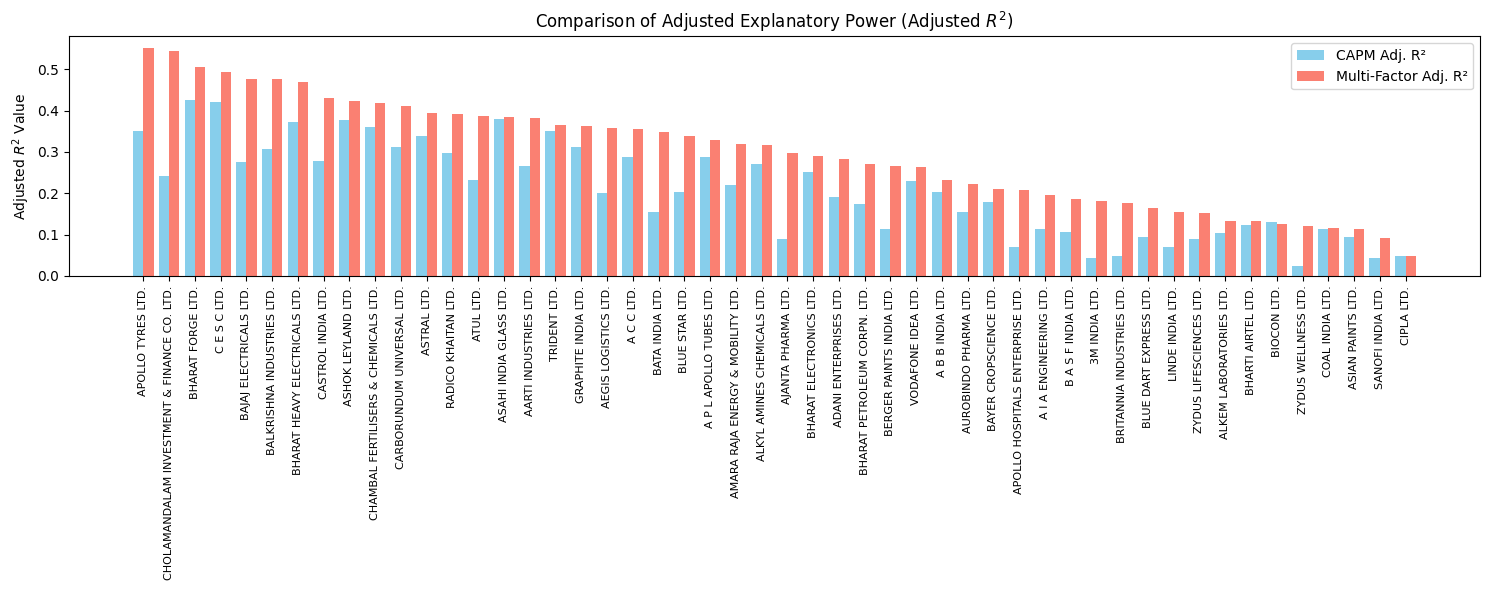

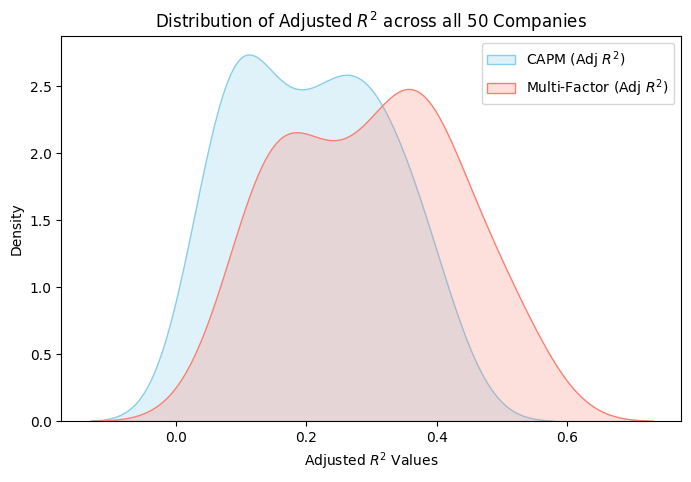

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data and setup Excess Returns
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

stocks = df['Co_Name'].unique()
results = []

# Loop to run regressions and extract Adjusted R2
for stock in stocks:
    s_df = df[df['Co_Name'] == stock]
    # CAPM
    res_capm = sm.OLS(s_df['Y'], sm.add_constant(s_df['Mkt_RF'])).fit()
    # Multi-Factor
    res_multi = sm.OLS(s_df['Y'], sm.add_constant(s_df[['Mkt_RF', 'SMB', 'HML', 'WML']])).fit()

    results.append({
        'Stock': stock,
        'CAPM_Adj_R2': res_capm.rsquared_adj,
        'Multi_Adj_R2': res_multi.rsquared_adj
    })

results_df = pd.DataFrame(results)

# --- GRAPH 1: Adjusted R-Squared Bar Chart ---
plt.figure(figsize=(15, 6))
r_sorted = results_df.sort_values('Multi_Adj_R2', ascending=False)
plt.bar(np.arange(len(r_sorted))-0.2, r_sorted['CAPM_Adj_R2'], 0.4, label='CAPM Adj. R²', color='skyblue')
plt.bar(np.arange(len(r_sorted))+0.2, r_sorted['Multi_Adj_R2'], 0.4, label='Multi-Factor Adj. R²', color='salmon')
plt.xticks(np.arange(len(r_sorted)), r_sorted['Stock'], rotation=90, fontsize=8)
plt.title('Comparison of Adjusted Explanatory Power (Adjusted $R^2$)')
plt.ylabel('Adjusted $R^2$ Value')
plt.legend()
plt.tight_layout()
plt.show()

# --- GRAPH 2: Adjusted R-Squared Distribution ---
plt.figure(figsize=(8, 5))
sns.kdeplot(results_df['CAPM_Adj_R2'], fill=True, label='CAPM (Adj $R^2$)', color='skyblue')
sns.kdeplot(results_df['Multi_Adj_R2'], fill=True, label='Multi-Factor (Adj $R^2$)', color='salmon')
plt.title('Distribution of Adjusted $R^2$ across all 50 Companies')
plt.xlabel('Adjusted $R^2$ Values')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Load your data
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045  # Monthly Risk-Free Rate
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

stocks = df['Co_Name'].unique()
comparison_results = []

print("Running 100 robust regressions and F-tests...")

for stock in stocks:
    try:
        # Create a clean subset for this stock with no missing values
        s_df = df[df['Co_Name'] == stock].dropna(subset=['Y', 'Mkt_RF', 'SMB', 'HML', 'WML'])

        # We need at least 10 months of data to run a regression
        if len(s_df) < 10:
            continue

        y = s_df['Y']

        # --- MODEL 1: CAPM (Restricted) ---
        X_capm = sm.add_constant(s_df['Mkt_RF'])
        res_capm = sm.OLS(y, X_capm).fit()

        # --- MODEL 2: MULTI-FACTOR (Unrestricted) ---
        X_multi = sm.add_constant(s_df[['Mkt_RF', 'SMB', 'HML', 'WML']])
        res_multi = sm.OLS(y, X_multi).fit()

        # --- THE F-TEST: Nested Model Comparison ---
        # This compares the models directly without needing string names
        f_stat, f_p_val, _ = res_multi.compare_f_test(res_capm)

        # --- STORAGE (Using .iloc[0] to avoid 'const' name errors) ---
        comparison_results.append({
            'Stock': stock,
            'CAPM_Adj_R2': res_capm.rsquared_adj,
            'Multi_Adj_R2': res_multi.rsquared_adj,
            'CAPM_Alpha': res_capm.params.iloc[0],  # Get the intercept by position
            'Multi_Alpha': res_multi.params.iloc[0], # Get the intercept by position
            'F_Stat': f_stat,
            'F_PValue': f_p_val,
            'Is_Multi_Better': 'Yes' if f_p_val < 0.05 else 'No'
        })

    except Exception as e:
        print(f"Skipping {stock} due to error: {e}")

# 2. Compile and Summary
summary_df = pd.DataFrame(comparison_results)
sig_count = (summary_df['Is_Multi_Better'] == 'Yes').sum()

print(f"\n--- FINAL ANALYSIS SUMMARY ---")
print(f"Total Stocks: {len(summary_df)}")
print(f"Stocks where Multi-Factor is significantly better than CAPM: {sig_count}")
print(f"Win Rate: {(sig_count/len(summary_df))*100:.1f}%")

# 3. Save the master file
summary_df.to_csv('Final_FTest_Comparison.csv', index=False)
print("\nFile 'Final_FTest_Comparison.csv' is ready in the sidebar.")

Running 100 robust regressions and F-tests...

--- FINAL ANALYSIS SUMMARY ---
Total Stocks: 50
Stocks where Multi-Factor is significantly better than CAPM: 34
Win Rate: 68.0%

File 'Final_FTest_Comparison.csv' is ready in the sidebar.


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Load Data
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

# 2. Split into Training (2018-2022) and Testing (2023)
train_df = df[df['Year'] < 2023]
test_df = df[df['Year'] == 2023]

stocks = df['Co_Name'].unique()
oos_results = []

print("Running Out-of-Sample Testing (Train on 2018-22, Predict 2023)...")

for stock in stocks:
    try:
        # Get data for this specific stock
        s_train = train_df[train_df['Co_Name'] == stock].dropna()
        s_test = test_df[test_df['Co_Name'] == stock].dropna()

        if len(s_train) < 12 or len(s_test) < 1:
            continue

        # --- PHASE 1: TRAIN (Estimate Betas) ---
        # CAPM Training
        res_capm = sm.OLS(s_train['Y'], sm.add_constant(s_train['Mkt_RF'])).fit()
        # Multi-Factor Training
        res_multi = sm.OLS(s_train['Y'], sm.add_constant(s_train[['Mkt_RF', 'SMB', 'HML', 'WML']])).fit()

        # --- PHASE 2: PREDICT (2023) ---
        # CAPM Prediction: Alpha + Beta * Market_2023
        pred_capm = res_capm.params.iloc[0] + res_capm.params.iloc[1] * s_test['Mkt_RF']

        # Multi-Factor Prediction: Alpha + (Betas * Factors_2023)
        pred_multi = res_multi.params.iloc[0] + (res_multi.params.iloc[1:] * s_test[['Mkt_RF', 'SMB', 'HML', 'WML']]).sum(axis=1)

        # --- PHASE 3: CALCULATE ERROR ---
        # Mean Absolute Error (How far off were we on average?)
        mae_capm = np.abs(s_test['Y'] - pred_capm).mean()
        mae_multi = np.abs(s_test['Y'] - pred_multi).mean()

        oos_results.append({
            'Stock': stock,
            'MAE_CAPM': mae_capm,
            'MAE_Multi': mae_multi,
            'Better_Model': 'Multi-Factor' if mae_multi < mae_capm else 'CAPM'
        })

    except Exception as e:
        continue

# 3. Final Summary
oos_summary = pd.DataFrame(oos_results)
avg_mae_capm = oos_summary['MAE_CAPM'].mean()
avg_mae_multi = oos_summary['MAE_Multi'].mean()
win_rate_multi = (oos_summary['Better_Model'] == 'Multi-Factor').mean() * 100

print(f"\n--- OUT-OF-SAMPLE RESULTS (2023) ---")
print(f"Average Error CAPM: {avg_mae_capm:.4f}")
print(f"Average Error Multi-Factor: {avg_mae_multi:.4f}")
print(f"Prediction Accuracy: Multi-Factor was better for {win_rate_multi:.1f}% of stocks.")

# Save for your report
oos_summary.to_csv('Out_of_Sample_Prediction_Results.csv', index=False)

Running Out-of-Sample Testing (Train on 2018-22, Predict 2023)...

--- OUT-OF-SAMPLE RESULTS (2023) ---
Average Error CAPM: 0.0608
Average Error Multi-Factor: 0.0612
Prediction Accuracy: Multi-Factor was better for 44.0% of stocks.
